## Composition-aware plaquette classes

The classes used below are the boundary-edge classes of the published construction,
with one change: the class key now also carries the **composition** of the plaquette.

Microstates are grouped by their outgoing boundary-edge 4-tuple, canonicalised over the
global $C_4$ rotation. Collapsing the four lab-frame images of a plaquette into one class
is exact — a rotation is a symmetry of the lattice, and it does not change what the
cluster is made of. But the boundary signature by itself does **not** fix the composition:
a site shows only its outward patches, so microstates with different particle counts can
expose the same boundary. Under the old key those were merged and Boltzmann-averaged into
a single class with a *fractional* $A_p$, which turns the constraint
$\sum_p A_p \rho_p = \phi$ into a mean-field smear and leaves the intra-class weights
depending on the $\mu$ used when the classes were built rather than the $\mu$ the solver
converges to. Orientational degeneracy is a real symmetry and may be collapsed;
compositional degeneracy is not, and must not be.

`composition_key="components"` (the new default) therefore keys a class on
(boundary signature, count per chemical component), where a component is a set of species
closed under `rot90_species` — for this particle that is `{0,1}` (the two orientations,
which are the *same* chemical species) versus `{2}` (the vacancy). Because components are
unions of rotation orbits, the count vector is $C_4$-invariant and separating on it leaves
the orientational collapse completely untouched.

**At $2\times2$ this does not change the answer.** Every site of a $2\times2$ plaquette is on
the perimeter and the vacancy carries its own patch type, so the boundary already
determines the occupancy: the class list is identical, class for class, to the published
one (checked in `spinodal_3x3_cluster_size_check.ipynb`). The distinction bites for
clusters with boundary-invisible sites ($3\times3$, the 7-site hexagon) and for models with
several chemical species (the chirality model), so the key is set explicitly here rather
than left implicit. Pass `composition_key="none"` to recover the published class
definition exactly.

In [1]:
# --- repo path setup (added during reorg) ---
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))


In [2]:
#!/usr/bin/env python
# coding: utf-8

import json
from typing import Optional, Tuple, Dict, Any

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull

try:
    from numba import njit as _njit
    _HAS_NUMBA = True
except ImportError:
    _HAS_NUMBA = False
    def _njit(*args, **kwargs):
        def _wrap(fn):
            return fn
        if args and callable(args[0]):
            return args[0]
        return _wrap

from plaquette_by_species import build_plaquettes_by_species


# --------------------------------------------------------------------------
# Helpers
# --------------------------------------------------------------------------

def loess_derivs(x, y, *, bandwidth=0.15, order=2):
    x = torch.as_tensor(x, dtype=torch.float64)
    y = torch.as_tensor(y, dtype=torch.float64)
    n = x.shape[0]
    f0 = torch.zeros(n, dtype=torch.float64)
    f1 = torch.zeros(n, dtype=torch.float64)
    f2 = torch.zeros(n, dtype=torch.float64)

    h = bandwidth * (x.max() - x.min())
    if float(h.item()) <= 0:
        h = torch.tensor(1.0, dtype=torch.float64)

    for i in range(n):
        d = (x - x[i]).abs()
        w = torch.clamp(1 - (d / h) ** 3, min=0) ** 3
        dx = x - x[i]
        cols = [torch.ones_like(dx)]
        if order >= 1:
            cols.append(dx)
        if order >= 2:
            cols.append(dx ** 2)
        X = torch.stack(cols, dim=1)
        XTW = (X.T * w)
        M = XTW @ X
        ridge = 1e-12 * torch.eye(M.shape[0], dtype=M.dtype, device=M.device)
        beta = torch.linalg.solve(M + ridge, XTW @ y)
        f0[i] = beta[0]
        f1[i] = beta[1] if order >= 1 else torch.nan
        f2[i] = (2 * beta[2]) if order >= 2 else torch.nan

    return f0, f1, f2


def zero_crossings_linear(phis, y, tol=1e-6):
    z = []
    for i in range(len(phis) - 1):
        y1, y2 = y[i], y[i + 1]
        if abs(y1) < tol:
            z.append(float(phis[i]))
            continue
        if y1 * y2 < 0:
            t = -y1 / (y2 - y1)
            z.append(float(phis[i] + t * (phis[i + 1] - phis[i])))
    if abs(y[-1]) < tol:
        z.append(float(phis[-1]))
    return z


def extract_binodals_from_convex_envelope(phi, f, *, coexist_tol=1e-5, min_gap_points=6):
    phi = np.asarray(phi, float)
    f = np.asarray(f, float)
    pts = np.column_stack([phi, f])

    try:
        hull = ConvexHull(pts)
    except Exception:
        return {"phi": phi, "f": f, "hull_idx": [], "segments": []}

    hull_idx = np.sort(hull.vertices)
    out = []

    for k in range(len(hull_idx) - 1):
        i, j = hull_idx[k], hull_idx[k + 1]
        if j - i < min_gap_points:
            continue

        phi1, phi2 = phi[i], phi[j]
        f1, f2 = f[i], f[j]
        mu_line = (f2 - f1) / (phi2 - phi1 + 1e-30)
        line = f1 + mu_line * (phi - phi1)
        diff = f - line
        mask = (phi >= phi1) & (phi <= phi2)
        if not np.any(mask):
            continue

        barrier = float(np.max(diff[mask]))
        below_min = float(np.min(diff[mask]))
        if barrier < coexist_tol:
            continue

        out.append({
            "phi1": float(phi1),
            "phi2": float(phi2),
            "mu": float(mu_line),
            "barrier": barrier,
            "below_min": below_min,
            "n_points": int(j - i),
        })

    return {"phi": phi, "f": f, "hull_idx": hull_idx.tolist(), "segments": out}


def best_binodal_segment(result, *, prefer="largest_barrier"):
    segs = result.get("segments", [])
    if not segs:
        return None
    if prefer == "widest":
        key = lambda d: (d["phi2"] - d["phi1"], d["barrier"])
    elif prefer == "most_points":
        key = lambda d: (d["n_points"], d["barrier"])
    else:
        key = lambda d: (d["barrier"], d["phi2"] - d["phi1"])
    return max(segs, key=key)


def common_tangent_line(phi, f, binodal):
    phi = np.asarray(phi, float)
    f = np.asarray(f, float)
    phi1 = float(binodal["phi1"])
    mu = float(binodal["mu"])
    f1 = float(np.interp(phi1, phi, f))
    c = f1 - mu * phi1
    line = mu * phi + c
    return line, c


def excess_above_tangent(phi, f, binodal):
    line, _ = common_tangent_line(phi, f, binodal)
    g = f - line
    return g, line


def plot_barrier(phi, f, binodal, *, ax=None):
    phi = np.asarray(phi, float)
    f = np.asarray(f, float)
    phi1 = float(binodal["phi1"])
    phi2 = float(binodal["phi2"])
    g, _ = excess_above_tangent(phi, f, binodal)

    if ax is None:
        _, ax = plt.subplots()

    ax.plot(phi, g, label="g(φ)=f(φ)-tangent")
    ax.axhline(0.0)
    ax.axvline(phi1)
    ax.axvline(phi2)
    ax.set_xlabel("φ")
    ax.set_ylabel("g(φ)")
    ax.legend()
    return ax


# --------------------------------------------------------------------------
# Reduced solver
# --------------------------------------------------------------------------

def build_S_matrix(patch_to_species, patch_to_small, m_patch, P, F):
    """
    Build S[i, s] = sum_{p: patch_to_species[p]=i, patch_to_small[p]=s} m_patch[p].
    """
    S = np.zeros((P, F), dtype=np.float64)
    for p in range(len(patch_to_species)):
        S[patch_to_species[p], patch_to_small[p]] += m_patch[p]
    return np.ascontiguousarray(S)


@_njit
def _eval_residual_reduced_square(mu, W, phi, S, delta, A, e, lm):
    """
    Evaluate reduced residual for square plaquettes (4-site cluster).

    Unknowns:
      mu : scalar density multiplier
      W  : F-dimensional free-face vector

    Returns:
      R   : residual vector of size 1+F
      rho : optimal plaquette-class weights at current (mu, W)
      X   : nonbonded fractions in face space
      pr  : total face abundances S^T rho
    """
    Fd = W.shape[0]
    P = A.shape[0]

    # --- X and h(X) from current W ---
    u = delta @ W
    X = np.empty(Fd)
    hv = np.empty(Fd)
    for s in range(Fd):
        xs = 1.0 / max(1.0 + u[s], 1e-12)
        xs = max(min(xs, 1.0), 1e-12)
        X[s] = xs
        hv[s] = np.log(max(xs, 1e-300)) - 0.5 * xs + 0.5

    # --- First-pass rho using envelope term only ---
    g0 = S @ hv
    lr = np.empty(P)
    mx = -1e300
    for i in range(P):
        v = 4.0 * mu * A[i] - e[i] - g0[i] + lm[i]
        lr[i] = v
        if v > mx:
            mx = v

    Z = 0.0
    rho = np.empty(P)
    for i in range(P):
        v = np.exp(lr[i] - mx)
        rho[i] = v
        Z += v

    inv_Z = 1.0 / Z
    for i in range(P):
        rho[i] *= inv_Z

    # pr = S^T rho
    pr = np.zeros(Fd)
    for i in range(P):
        ri = rho[i]
        for s in range(Fd):
            pr[s] += S[i, s] * ri

    # --- Implicit derivative correction ---
    K = np.empty((Fd, Fd))
    for s in range(Fd):
        xs2 = X[s] * X[s]
        for sp in range(Fd):
            K[s, sp] = xs2 * delta[s, sp] * pr[sp]

    dAdX = np.empty(Fd)
    for s in range(Fd):
        dAdX[s] = pr[s] * (1.0 / max(X[s], 1e-12) - 0.5)

    Msys = np.empty((Fd, Fd))
    for s in range(Fd):
        for sp in range(Fd):
            Msys[s, sp] = K[sp, s]   # K^T
        Msys[s, s] += 1.0 + 1e-12

    alpha = np.linalg.solve(Msys, dAdX)

    beta = np.zeros(Fd)
    for s in range(Fd):
        acc = 0.0
        for sp in range(Fd):
            acc += delta[sp, s] * alpha[sp] * X[sp] * X[sp]
        beta[s] = -acc

    hv_corr = np.empty(Fd)
    for s in range(Fd):
        hv_corr[s] = hv[s] + beta[s] * X[s]

    # --- Rebuild rho using corrected association gradient ---
    g = S @ hv_corr
    mx = -1e300
    for i in range(P):
        v = 4.0 * mu * A[i] - e[i] - g[i] + lm[i]
        lr[i] = v
        if v > mx:
            mx = v

    Z = 0.0
    for i in range(P):
        v = np.exp(lr[i] - mx)
        rho[i] = v
        Z += v

    inv_Z = 1.0 / Z
    for i in range(P):
        rho[i] *= inv_Z

    pr[:] = 0.0
    for i in range(P):
        ri = rho[i]
        for s in range(Fd):
            pr[s] += S[i, s] * ri

    # Residual:
    # R0 = A^T rho - phi
    # Rs = W_s - X_s * pr_s
    R = np.empty(1 + Fd)
    phi_rho = 0.0
    for i in range(P):
        phi_rho += A[i] * rho[i]
    R[0] = phi_rho - phi

    for s in range(Fd):
        R[1 + s] = W[s] - X[s] * pr[s]

    return R, rho, X, pr


@_njit
def _find_initial_mu_square(phi_target, A, lm, e, S, delta, W):
    """
    Scalar solve for mu using the envelope-only face field from the current W.
    """
    Fd = W.shape[0]
    P = A.shape[0]

    u = delta @ W
    X = np.empty(Fd)
    hv = np.empty(Fd)
    for s in range(Fd):
        xs = 1.0 / max(1.0 + u[s], 1e-12)
        xs = max(min(xs, 1.0), 1e-12)
        X[s] = xs
        hv[s] = np.log(max(xs, 1e-300)) - 0.5 * xs + 0.5

    g = S @ hv

    mu_lo = -100.0
    mu_hi = 100.0
    mu = 0.0

    for _ in range(120):
        mx = -1e300
        for i in range(P):
            v = 4.0 * mu * A[i] - e[i] - g[i] + lm[i]
            if v > mx:
                mx = v

        Z = 0.0
        phi_mu = 0.0
        dphi = 0.0

        for i in range(P):
            v = np.exp(4.0 * mu * A[i] - e[i] - g[i] + lm[i] - mx)
            Z += v
        inv_Z = 1.0 / Z

        for i in range(P):
            ri = np.exp(4.0 * mu * A[i] - e[i] - g[i] + lm[i] - mx) * inv_Z
            phi_mu += A[i] * ri
            dphi += 4.0 * A[i] * A[i] * ri
        dphi -= 4.0 * phi_mu * phi_mu  # dphi/dmu = 4 * Var_rho(A)

        err = phi_mu - phi_target
        if abs(err) < 1e-12:
            break

        if err > 0.0:
            mu_hi = mu
        else:
            mu_lo = mu

        if abs(dphi) > 1e-30:
            mu_new = mu - err / dphi
            if mu_new < mu_lo or mu_new > mu_hi:
                mu_new = 0.5 * (mu_lo + mu_hi)
        else:
            mu_new = 0.5 * (mu_lo + mu_hi)

        mu = mu_new

    return mu


@_njit
def _solve_single_phi_reduced_square(phi, mu0, W0, S, delta, A, e, lm,
                                     max_newton=80, tol=1e-10):
    """
    Solve one phi point in reduced variables (mu, W) for square plaquettes.
    """
    Fd = W0.shape[0]
    n_p = 1 + Fd
    h_fd = 1e-7

    mu = mu0
    W = W0.copy()

    R0, _, _, _ = _eval_residual_reduced_square(mu, W, phi, S, delta, A, e, lm)
    rn0 = 0.0
    for k in range(n_p):
        rn0 += R0[k] * R0[k]
    rn0 = np.sqrt(rn0)

    if rn0 > 0.1:
        mu = _find_initial_mu_square(phi, A, lm, e, S, delta, W)

    it_done = 0
    for it in range(max_newton):
        it_done = it + 1
        R, rho, X, pr = _eval_residual_reduced_square(mu, W, phi, S, delta, A, e, lm)

        rn = 0.0
        for k in range(n_p):
            rn += R[k] * R[k]
        rn = np.sqrt(rn)

        if rn < tol:
            break

        Jac = np.empty((n_p, n_p))

        Rp, _, _, _ = _eval_residual_reduced_square(mu + h_fd, W, phi, S, delta, A, e, lm)
        for k in range(n_p):
            Jac[k, 0] = (Rp[k] - R[k]) / h_fd

        for j in range(Fd):
            Wp = W.copy()
            Wp[j] += h_fd
            Rp2, _, _, _ = _eval_residual_reduced_square(mu, Wp, phi, S, delta, A, e, lm)
            for k in range(n_p):
                Jac[k, 1 + j] = (Rp2[k] - R[k]) / h_fd

        for k in range(n_p):
            Jac[k, k] += 1e-12

        dp = np.linalg.solve(Jac, -R)
        for k in range(n_p):
            if dp[k] > 10.0:
                dp[k] = 10.0
            elif dp[k] < -10.0:
                dp[k] = -10.0

        alpha = 1.0
        best_rn_ls = rn
        for _ in range(20):
            mn = mu + alpha * dp[0]
            Wn = W + alpha * dp[1:]
            Rn, _, _, _ = _eval_residual_reduced_square(mn, Wn, phi, S, delta, A, e, lm)

            rn_ls = 0.0
            for k in range(n_p):
                rn_ls += Rn[k] * Rn[k]
            rn_ls = np.sqrt(rn_ls)

            if rn_ls < best_rn_ls:
                break
            alpha *= 0.5

        mu += alpha * dp[0]
        W += alpha * dp[1:]

    R, rho, X, pr = _eval_residual_reduced_square(mu, W, phi, S, delta, A, e, lm)
    rn_final = 0.0
    for k in range(n_p):
        rn_final += R[k] * R[k]
    rn_final = np.sqrt(rn_final)

    hv = np.empty(Fd)
    for s in range(Fd):
        hv[s] = np.log(max(X[s], 1e-300)) - 0.5 * X[s] + 0.5

    A_mix = 0.0
    P = A.shape[0]
    for i in range(P):
        A_mix += rho[i] * (np.log(max(rho[i], 1e-300)) - lm[i])

    A_lin = 0.0
    for i in range(P):
        A_lin += e[i] * rho[i]

    A_assoc = 0.0
    for s in range(Fd):
        A_assoc += hv[s] * pr[s]

    f = (A_mix + A_lin + A_assoc) / 4.0
    return f, mu, W, rn_final, it_done


def solve_free_energy_curve_reduced_square(
    phi_grid,
    A_row,
    e_linear,
    log_mult,
    S,
    delta_small_np,
    *,
    mu_init=0.0,
    W_init=None,
    max_newton=80,
    tol=1e-9,
    accept_residual=1e-6,
):
    """
    Sweep f(phi) using reduced Newton for the square plaquette case.
    """
    phi_grid = np.asarray(phi_grid, dtype=np.float64)
    A_row = np.ascontiguousarray(np.asarray(A_row, dtype=np.float64))
    e_linear = np.ascontiguousarray(np.asarray(e_linear, dtype=np.float64))
    log_mult = np.ascontiguousarray(np.asarray(log_mult, dtype=np.float64))
    S = np.ascontiguousarray(np.asarray(S, dtype=np.float64))
    delta_small_np = np.ascontiguousarray(np.asarray(delta_small_np, dtype=np.float64))

    Fd = S.shape[1]
    phi_lo, phi_hi = float(A_row.min()), float(A_row.max())

    fvals = np.full(len(phi_grid), np.nan, dtype=np.float64)
    mus = np.full(len(phi_grid), np.nan, dtype=np.float64)

    mu = float(mu_init)
    W = np.zeros(Fd, dtype=np.float64) if W_init is None else np.asarray(W_init, dtype=np.float64).copy()

    for k, phi in enumerate(phi_grid):
        phi = float(phi)
        if phi < phi_lo - 1e-12 or phi > phi_hi + 1e-12:
            continue

        f, mu, W, res, _ = _solve_single_phi_reduced_square(
            phi, mu, W, S, delta_small_np, A_row, e_linear, log_mult,
            max_newton=max_newton, tol=tol
        )
        mus[k] = mu
        if np.isfinite(f) and res <= accept_residual:
            fvals[k] = f

    return {
        "phi": phi_grid,
        "f": fvals,
        "mus": mus,
        "mu_W": (float(mu), W.copy()),
    }


# --------------------------------------------------------------------------
# Square scan using reduced solver
# --------------------------------------------------------------------------

def find_spinodal_simple_reduced(
    patches,
    eps_as,
    eps_cs,
    factor,
    *,
    z=4,
    rot90_species=None,
    phis=None,
    tol_newton=1e-9,
    max_newton=120,
    plot_each=False,
    canonicalize_by_boundary_edges=True,
    canonicalize_by_edges=False,
    use_4_patch=True,
    composition_key="components",
):
    _reported_composition = False
    """
    Reduced square-lattice scan.
    This implementation is intended for use_4_patch=True.
    """
    if not use_4_patch:
        raise ValueError("This reduced implementation is written for use_4_patch=True.")
    if not canonicalize_by_boundary_edges:
        raise ValueError("Use canonicalize_by_boundary_edges=True for this reduced implementation.")
    if canonicalize_by_edges:
        raise ValueError("Do not use canonicalize_by_edges=True together with boundary-edge canonicalization.")

    phis = np.linspace(0.01, 0.99, 151) if phis is None else np.asarray(phis, dtype=float)
    eps_as = np.asarray(eps_as, dtype=float)
    eps_cs = np.asarray(eps_cs, dtype=float)

    points = []
    binodals = []
    prev_mu_W = None

    n_patch_types = int(np.max(patches)) + 1

    for eps_c in eps_cs:
        for eps_a in eps_as:
            J = np.zeros((n_patch_types, n_patch_types), dtype=np.float64)
            J[1, 1] = -float(eps_a)
            J[:-1, :-1] -= float(eps_c)

            mu_species = np.zeros(len(patches), dtype=np.float64)

            (
                eps_s,
                intra_bonds,
                plaq_to_species,
                m_patch,
                patch_to_species,
                patch_to_small,
                plaq_configs,
                mult,
            ) = build_plaquettes_by_species(
                patches,
                J,
                mu_species,
                rot90_species=rot90_species,
                canonicalize_by_boundary_edges=canonicalize_by_boundary_edges,
                canonicalize_by_edges=canonicalize_by_edges,
                use_4_patch=use_4_patch,
                # Class key = (boundary signature, chemical composition).
                # "none" reproduces the published boundary-only key.
                composition_key=composition_key,
            )

            # A_row = occupancy fraction (last species assumed vacancy)
            A_row = np.sum(plaq_to_species[:, :-1], axis=1).astype(np.float64) / 4.0

            # A composition-aware class holds an integer number of particles, so
            # 4*A_row must be an integer.  Under the legacy boundary-only key it
            # need not be, and the composition constraint is then a mean-field
            # smear rather than exact bookkeeping.  Reported once per scan.
            _nonint = float(np.abs(4.0 * A_row - np.rint(4.0 * A_row)).max())
            if not _reported_composition:
                print(f"  composition_key={composition_key!r}: P={len(A_row)}, "
                      f"max|4*A_p - round(4*A_p)| = {_nonint:.3e}")
                _reported_composition = True

            P = int(len(A_row))
            Fd = int(np.max(patch_to_small)) + 1
            S_mat = build_S_matrix(patch_to_species, patch_to_small, m_patch, P, Fd)

            log_mult_np = np.log(mult.astype(np.float64) + 1e-300)
            delta_np = (np.exp(-eps_s) - 1.0) / float(factor)

            mu0, W0 = (prev_mu_W if prev_mu_W is not None else (0.0, None))

            curve = solve_free_energy_curve_reduced_square(
                phis,
                A_row,
                intra_bonds.astype(np.float64),
                log_mult_np,
                S_mat,
                delta_np,
                mu_init=mu0,
                W_init=W0,
                max_newton=max_newton,
                tol=tol_newton,
                accept_residual=max(1e-6, 10.0 * tol_newton),
            )
            prev_mu_W = curve["mu_W"]

            phi_arr = np.asarray(curve["phi"], float)
            f_arr = np.asarray(curve["f"], float)

            valid = ~np.isnan(f_arr)
            phi_v = phi_arr[valid]
            f_v = f_arr[valid]
            if len(phi_v) < 5:
                continue

            margin = min(2, len(phi_v) // 4)
            phi_inner = phi_v[margin:-margin] if margin > 0 else phi_v
            f_inner = f_v[margin:-margin] if margin > 0 else f_v
            if len(phi_inner) < 5:
                continue

            f_smooth_t, _, fpp_t = loess_derivs(phi_inner, f_inner)
            f_smooth = f_smooth_t.detach().cpu().numpy()
            sp = zero_crossings_linear(phi_inner, -fpp_t.detach().cpu().numpy(), tol=1e-6)

            res = extract_binodals_from_convex_envelope(
                phi_inner, f_smooth, coexist_tol=1e-5, min_gap_points=6
            )
            binodal = best_binodal_segment(res, prefer="largest_barrier")

            if binodal is not None and binodal["barrier"] > 1e-4:
                points.append((float(eps_a), float(eps_c)))
                out = dict(binodal)
                out["spinodal_phis"] = [float(x) for x in sp]
                out["eps_a"] = float(eps_a)
                out["eps_c"] = float(eps_c)
                binodals.append(out)

                if plot_each:
                    plot_barrier(phi_inner, f_smooth, binodal)
                    plt.title(f"eps_a={eps_a:.3f}, eps_c={eps_c:.3f}")
                    plt.show()

    return binodals, points


# --------------------------------------------------------------------------
# Optional save helper
# --------------------------------------------------------------------------

def save_spinodal_simple_results(
    binodals,
    points,
    eps_as,
    eps_cs,
    factor,
    patches,
    rot90_species,
    z,
    canonicalize_by_boundary_edges,
    canonicalize_by_edges,
    use_4_patch,
    base_filename="../data/spinodal_simple_reduced_square_results",
):
    filename = f"{base_filename}.npz"
    metadata_filename = f"{base_filename}_metadata.json"

    save_dict = {
        "points": np.array(points, dtype=np.float64).reshape(-1, 2) if len(points) else np.empty((0, 2), dtype=np.float64),
        "eps_as": np.asarray(eps_as, dtype=np.float64),
        "eps_cs": np.asarray(eps_cs, dtype=np.float64),
    }

    if len(binodals):
        save_dict["binodal_phi1"] = np.array([b.get("phi1", np.nan) for b in binodals], dtype=np.float64)
        save_dict["binodal_phi2"] = np.array([b.get("phi2", np.nan) for b in binodals], dtype=np.float64)
        save_dict["binodal_barrier"] = np.array([b.get("barrier", np.nan) for b in binodals], dtype=np.float64)
        save_dict["binodal_eps_a"] = np.array([b.get("eps_a", np.nan) for b in binodals], dtype=np.float64)
        save_dict["binodal_eps_c"] = np.array([b.get("eps_c", np.nan) for b in binodals], dtype=np.float64)
    else:
        save_dict["binodal_phi1"] = np.array([], dtype=np.float64)
        save_dict["binodal_phi2"] = np.array([], dtype=np.float64)
        save_dict["binodal_barrier"] = np.array([], dtype=np.float64)
        save_dict["binodal_eps_a"] = np.array([], dtype=np.float64)
        save_dict["binodal_eps_c"] = np.array([], dtype=np.float64)

    np.savez_compressed(filename, **save_dict)

    metadata = {
        "factor": float(factor),
        "z": int(z),
        "canonicalize_by_boundary_edges": bool(canonicalize_by_boundary_edges),
        "canonicalize_by_edges": bool(canonicalize_by_edges),
        "use_4_patch": bool(use_4_patch),
        "patches_shape": list(patches.shape),
        "rot90_species": None if rot90_species is None else rot90_species.tolist(),
        "n_points": int(len(points)),
        "n_binodals": int(len(binodals)),
        "eps_as_range": [float(np.min(eps_as)), float(np.max(eps_as))],
        "eps_cs_range": [float(np.min(eps_cs)), float(np.max(eps_cs))],
    }

    with open(metadata_filename, "w") as f:
        json.dump(metadata, f, indent=2)

    print(f"Saved {filename}")
    print(f"Saved {metadata_filename}")


# --------------------------------------------------------------------------
# Example usage matching your current square case
# --------------------------------------------------------------------------

if __name__ == "__main__":
    patches = np.array([
        [1, 0, 1, 0],
        [0, 1, 0, 1],
        [2, 2, 2, 2],  # vacancy
    ], dtype=np.int64)

    # species 0 <-> 1 under 90° rotation, vacancy fixed
    rot90_species = np.array([1, 0, 2], dtype=np.int64)

    z = 4
    eps_as = np.linspace(0.0, 10.0, 51)
    eps_cs = np.concatenate([
        np.linspace(0.0, 0.5, 11),
        np.linspace(0.5, 0.7, 41)[1:],
        np.linspace(0.7, 2.1, 11)[1:]
    ])

    # For use_4_patch=True in this square builder, keep factor=4
    factor = 4

    print(f"Patches shape: {patches.shape}")
    print(f"Grid: {len(eps_as)} eps_a x {len(eps_cs)} eps_c = {len(eps_as) * len(eps_cs)} points")
    print(f"Factor: {factor}")

    binodals, points = find_spinodal_simple_reduced(
        patches,
        eps_as,
        eps_cs,
        factor,
        z=z,
        rot90_species=rot90_species,
        phis=np.linspace(0.01, 0.99, 151),
        tol_newton=1e-8,
        max_newton=180,
        plot_each=False,
        canonicalize_by_boundary_edges=True,
        canonicalize_by_edges=False,
        use_4_patch=True,
    )

    print(f"Found {len(points)} binodal points.")

    save_spinodal_simple_results(
        binodals,
        points,
        eps_as,
        eps_cs,
        factor,
        patches,
        rot90_species,
        z,
        canonicalize_by_boundary_edges=True,
        canonicalize_by_edges=False,
        use_4_patch=True,
        base_filename="../data/spinodal_simple_reduced_square_use4patch",
    )

Patches shape: (3, 4)
Grid: 51 eps_a x 61 eps_c = 3111 points
Factor: 4
  composition_key='components': P=24, max|4*A_p - round(4*A_p)| = 0.000e+00
Found 1526 binodal points.
Saved ../data/spinodal_simple_reduced_square_use4patch.npz
Saved ../data/spinodal_simple_reduced_square_use4patch_metadata.json


Loaded: ../data/spinodal_simple_reduced_square_use4patch.npz
Number of points: 1526


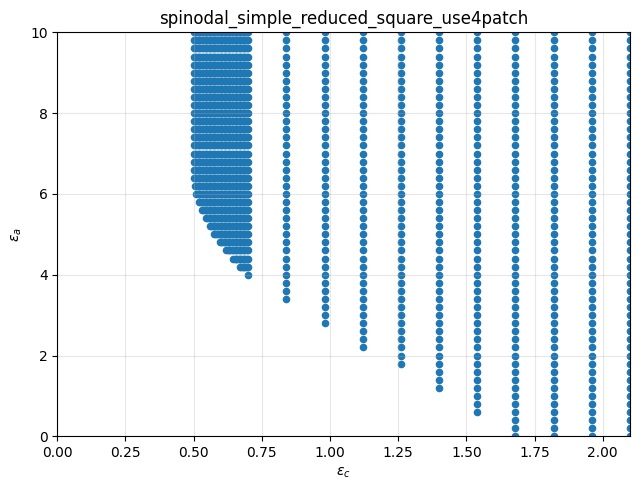

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt

base_candidates = [
    "../data/spinodal_simple_reduced_square_use4patch.npz",
]

npz_path = None
for p in base_candidates:
    if os.path.exists(p):
        npz_path = p
        break

if npz_path is None:
    # search a bit
    for root, dirs, files in os.walk("/mnt/data"):
        for f in files:
            if f == "../data/spinodal_simple_reduced_square_use4patch.npz":
                npz_path = os.path.join(root, f)
                break
        if npz_path:
            break

if npz_path is None:
    raise FileNotFoundError("Could not find spinodal_simple_reduced_square_use4patch.npz")

data = np.load(npz_path)

points = data["points"] if "points" in data else np.empty((0, 2))
eps_as = data["eps_as"] if "eps_as" in data else None
eps_cs = data["eps_cs"] if "eps_cs" in data else None

fig, ax = plt.subplots(figsize=(6.5, 5.0))
if points.size:
    ax.scatter(points[:, 1], points[:, 0], s=20)
else:
    ax.text(0.5, 0.5, "No points found", ha="center", va="center", transform=ax.transAxes)

ax.set_ylabel(r"$\epsilon_a$")
ax.set_xlabel(r"$\epsilon_c$")
ax.set_title("spinodal_simple_reduced_square_use4patch")

if eps_as is not None and len(eps_as):
    ax.set_ylim(float(np.min(eps_as)), float(np.max(eps_as)))
if eps_cs is not None and len(eps_cs):
    ax.set_xlim(float(np.min(eps_cs)), float(np.max(eps_cs)))

ax.grid(True, alpha=0.3)
fig.tight_layout()


print(f"Loaded: {npz_path}")
print(f"Number of points: {len(points)}")
plt.show()
